# AdaBoost

AdaBoost is short for *Adaptive Boosting* and is a sequential (boosting) ensemble method usually used for binary classification problems. AdaBoost works by iteratively training a sequence of weak classifiers on different subsets of the training data. During each iteration, the algorithm assigns higher and higher weights to the misclassified samples from the previous iteration, thereby focusing on the more challenging examples. This process allows the subsequent weak classifiers to pay more attention to the previously misclassified samples and improve their performance.

The following pseudocode outlines the step-by-step process of the AdaBoost algorithm `[1]`:

```
Initialize sample weights for each training example
For each iteration:
- Train a weak classifier using the current sample weights
- Calculate the error of the weak classifier
- Calculate the weight of the weak classifier based on the error
- Update the sample weights based on the weak classifier's performance
- Normalize the sample weights
End the iterations
Combine the weak classifiers using a weighted majority vote.
```

Advantages of AdaBoost:

1. High Level of Accuracy:
AdaBoost combines weak learners to create a strong classifier that can significantly improve predictive performance across various domains.

2. High Degree of Explainability:
If the model fails at some point, you have a sense of which weak learner is to blame, allowing for more transparent model interpretation.

3. Handles Both Classification and Regression:
The algorithm can be effectively applied to both categorical and continuous prediction problems, making it versatile across different machine learning tasks.

4. Computationally Efficient:
AdaBoost requires relatively low computational resources compared to more complex ensemble methods, enabling faster model training.

5. Reduces Bias and Variance:
By iteratively focusing on misclassified instances, AdaBoost helps reduce both model bias and variance, leading to more robust predictions.

6. Works Well with a Variety of Weak Learners
The algorithm can integrate different types of weak classifiers, such as linear models or simple neural networks.

7. Naturally Handles Feature Selection:
Through its iterative weighting process, AdaBoost inherently identifies and emphasizes the most informative features for prediction.

8. Somewhat Robust to Overfitting Compared to Single Complex Models:
The ensemble approach helps prevent overfitting by combining multiple simple models rather than relying on a single complex model.

Disadvantages of AdaBoost:

1. Sensitivity to Outliers:
Extreme or noisy data points can disproportionately influence the model's learning process, potentially skewing predictions.

2. Moderately Prone to Overfitting:
If the weak classifiers are too complex or the number of boosting iterations is too high, the model may memorize training data instead of generalizing.

3. Computationally Intensive for Large Datasets:
As the algorithm processes data sequentially, training can become time-consuming with very large or high-dimensional datasets.

4. Requires Careful Hyperparameter Tuning:
Selecting the optimal number of weak learners and their complexity demands significant experimentation and domain expertise.

5. Assumes Weak Learners are Better than Random Guessing:
The algorithm's effectiveness depends on weak learners performing slightly better than chance, which isn't always guaranteed.

6. Performance Degrades with Noisy Data:
Inconsistent or low-quality training data can significantly reduce the model's predictive performance.

7. Potentially Unstable with Highly Imbalanced Datasets:
When class distributions are extremely uneven, AdaBoost might struggle to learn effectively across all classes.

8. Can Struggle with High-Dimensional Data:
The algorithm's performance may decline when dealing with datasets containing numerous features.

9. Less Effective with Highly Correlated Features:
When input features are strongly correlated, AdaBoost might not distribute weights as effectively.

❓ Question:

✍🏼 In order to edit this notebook, make a copy and save it in your Google Drive.

## Getting Started

In this notebook, we'll be using AdaBoost to classify wild mushrooms as either poisonous or edible based on features such as cap color, odor, and gill color. This project is based on the work of Tharun Nayak, whose complete work can be found in the *Sources and Further Reading* section.

### Set Up and Problem Clarification

💾 Download the dataset [here](https://www.kaggle.com/code/tharunnayak14/mushroom-classification-using-adaboost/input?select=mushrooms.csv).

This dataset has a lot of categorical data, so let's first take a look at some of the attributes and what the abbreviations mean:

- cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s
- cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
- cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r, pink=p,purple=u,red=e,white=w,yellow=y
- bruises?: bruises=t,no=f
- odor: almond=a,anise=l,creosote=c,fishy=y,foul=f, musty=m,none=n,pungent=p,spicy=s
- gill-attachment: attached=a,descending=d,free=f,notched=n
- gill-spacing: close=c,crowded=w,distant=d
- gill-size: broad=b,narrow=n
- gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e, white=w,yellow=y
- stalk-shape: enlarging=e,tapering=t
- stalk-root: bulbous=b,club=c,cup=u,equal=e, rhizomorphs=z,rooted=r,missing=?
- stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
- stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
- stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
- stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o, pink=p,red=e,white=w,yellow=y
- veil-type: partial=p,universal=u
- veil-color: brown=n,orange=o,white=w,yellow=y
- ring-number: none=n,one=o,two=t
- ring-type: cobwebby=c,evanescent=e,flaring=f,large=l, none=n,pendant=p,sheathing=s,zone=z
- spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r, orange=o,purple=u,white=w,yellow=y
- population: abundant=a,clustered=c,numerous=n, scattered=s,several=v,solitary=y
- habitat: grasses=g,leaves=l,meadows=m,paths=p, urban=u,waste=w,woods=d

If you're not a big mushroom forager, some good rules to apply for avoiding poisonous mushrooms include:

1. Avoid mushrooms with white gills, a skirt, a ring on the stem, and a bulbous base.
2. Avoid mushrooms with red on the cap or stem.
3. Don't ever eat a mushroom if you're not 100% sure of what it is.

These rules, however, would cause us to miss out on some good, edible fungi, and don't include all poisonous mushroom species. Therefore, we've found a fascinating classification problem; there's no hard and fast rule for determining whether a mushroom is poisonous or not without knowing the species.

Let's get started by importing our dataset and necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### EDA

"*EDA is not optional — it's essential. You need to understand your dataset before throwing an algorithm at it, and this becomes doubly important with AdaBoost, which can be sensitive to the quality of input data*" `[4]`.

To get a feel for our dataset, let's find out if it is balanced or unbalanced. Note that our target variable's values are 'p' for poisonous or 'e' for edible.

✅ **Try it yourself**: Plot the target variable as a bar chart.

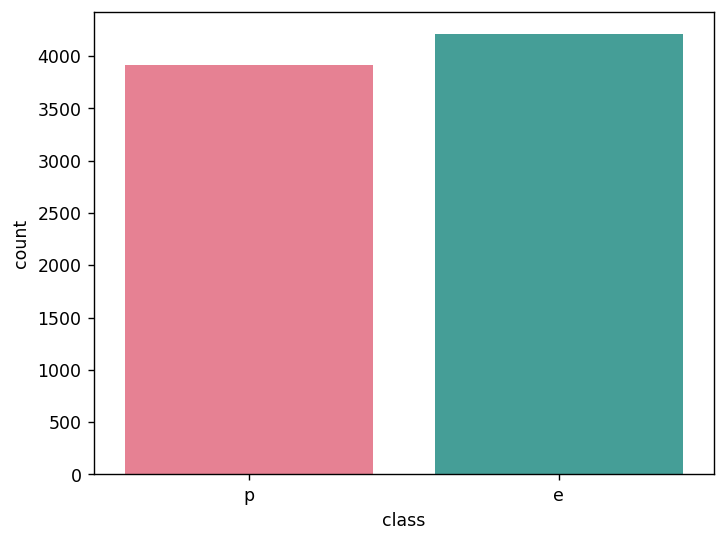

In [3]:
# Your Code Here

plt.figure(dpi=125)
sns.countplot(data=df,x='class', hue = 'class', palette = "husl")
plt.show()

**❓Question**: Is the dataset fairly balanced?

Now, let's get a feel for variation in our dataset by determining which features have the most unique categories.

✅ **Try it yourself**: Plot the number of unique categories in each of the feature columns.

<ipython-input-4-57768478e8c4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= df.describe().transpose().reset_index().sort_values('unique'),x='index',y='unique', palette = "husl")


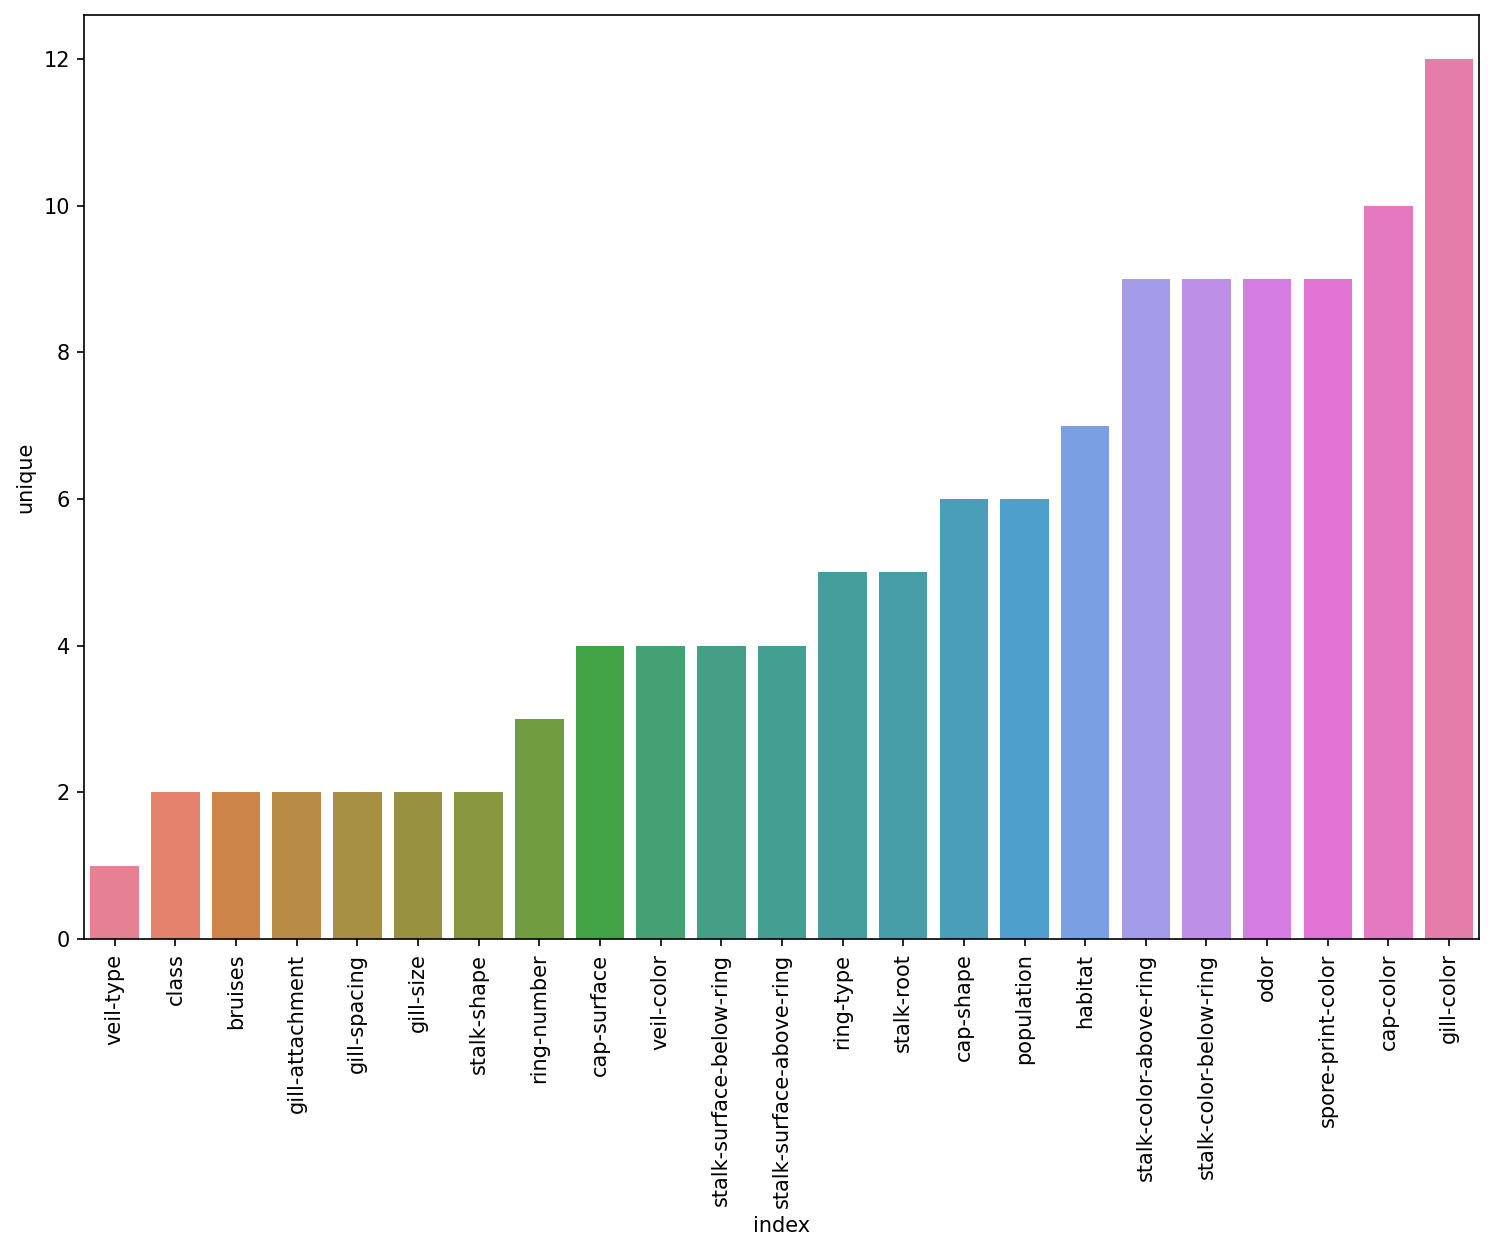

In [4]:
# Your Code Here

plt.figure(dpi=150,figsize=(12,8))
sns.barplot(data= df.describe().transpose().reset_index().sort_values('unique'),x='index',y='unique', palette = "husl")
plt.xticks(rotation=90);

**❓Question**: Which feature has the most unique values?

**❕Answer:** gill-color

### Preprocessing

In order to prepare our dataset for model implementation, we need to:

1. Check for missing/duplicate values
2. Encode categorical variables
3. Split the data into features and target
4. Split the data into training and test sets, 85% used for training

✅ **Try it yourself**: Take the above preprocessing steps to ensure our dataset is ready.

In [5]:
# Your Code Here

# Check for Missing/Duplicate Values
# print(df.isnull().sum())
# print(df.duplicated().sum)

# Split data into features/target
X = df.drop(columns='class')
y = df['class']

# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Take a look at our work
X_train.head()

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
3290,False,True,False,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
1703,False,True,False,False,False,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,False
228,False,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
7706,True,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2513,False,True,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


**❓Question**: Does AdaBoost require feature scaling?

**❕Answer: ** No!

## Model Implementation

AdaBoost could excel with mushroom classification due to its core mechanism of iteratively focusing on misclassified instances. In the context of mushroom identification, this is crucial because misclassification of mushrooms has high stakes - distinguishing poisonous from edible is a life-or-death task.

AdaBoost's sequential learning would incrementally improve classification by:

1. Initially learning basic mushroom features that differentiate poisonous and edible specimens
2. Progressively giving more weight to complex or ambiguous mushroom characteristics that initial models struggled to classify correctly
3. Creating an ensemble where later models specialize in the "edge cases" that earlier models missed

Hopefully, our algorithm will develop increasingly nuanced decision boundaries by emphasizing mushroom traits like cap shape, gill characteristics, spore print color, and habitat - features that might have subtle differences between poisonous and safe species.

### Hyperparameter Tuning

When dealing with complex classification problems like identifying mushrooms, we often face a challenge: how do we fine-tune our machine learning model to capture subtle, nuanced distinctions? This is where the concept of hyperparameter tuning comes into play.

In our mushroom classification scenario, we'll systematically experiment with the number of estimators (the number of weak learners/base models in the ensemble) in AdaBoost. By methodically exploring these variations, we can find the sweet spot where our model becomes most accurate, minimizing misclassification risks, without overfitting.

Let's start by systematically testing different numbers of estimators (base models) to find the optimal configuration:

Key Components of Our Approach:

- `error_list`: Tracks classification error for each number of estimators
- Iterates through 1-95 estimators (there are 95 columns total)
- For each iteration:
    - Creates AdaBoostClassifier with current number of estimators
    - Trains model on training data
    - Makes predictions on test data
    - Calculates error (1 - accuracy)
    - Appends error to list

The goal is to identify the n_estimators value that minimizes classification error. The code recognizes that after a certain point, adding more estimators provides diminishing returns in model performance.

In [6]:
from sklearn.ensemble import AdaBoostClassifier # Import Classifier
from sklearn.metrics import accuracy_score      # Import accuracy score

error_list = []

# Iterate through n_estimators to generate error_list
for i in range (1, len(X.columns) + 1):
    model = AdaBoostClassifier(n_estimators=i)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    error = 1 - accuracy_score(y_test, predictions)
    error_list.append(error)

print(error_list)

[0.11648892534864641, 0.11648892534864641, 0.07957342083675145, 0.07957342083675145, 0.06234618539786707, 0.04265791632485649, 0.025430680885972112, 0.041837571780147687, 0.041837571780147687, 0.041837571780147687, 0.05660377358490565, 0.03199343724364234, 0.03199343724364234, 0.027071369975389614, 0.027071369975389614, 0.027071369975389614, 0.027071369975389614, 0.027071369975389614, 0.027071369975389614, 0.018047579983593076, 0.025430680885972112, 0.028712059064807227, 0.025430680885972112, 0.025430680885972112, 0.025430680885972112, 0.025430680885972112, 0.024610336341263306, 0.025430680885972112, 0.02132895816242819, 0.016406890894175574, 0.02132895816242819, 0.01312551271534046, 0.02132895816242819, 0.009023789991796538, 0.012305168170631653, 0.022149302707136997, 0.022149302707136997, 0.01968826907301069, 0.009023789991796538, 0.009023789991796538, 0.004922067268252617, 0.018047579983593076, 0.009023789991796538, 0.009023789991796538, 0.009023789991796538, 0.004922067268252617, 0

✅ **Try it yourself**: Create a line plot with the number of estimators on the x axis and the error on the y axis.

In [7]:
# Your Code Here

# One solution

import plotly.express as px
fig = px.line(x=range(1,96), y=error_list,labels=dict(x="n_estimators", y="error"))
fig.show()

<ipython-input-13-9c0307ef7904>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=range(1, len(X.columns)), y=error_list, marker='o', palette = "husl")


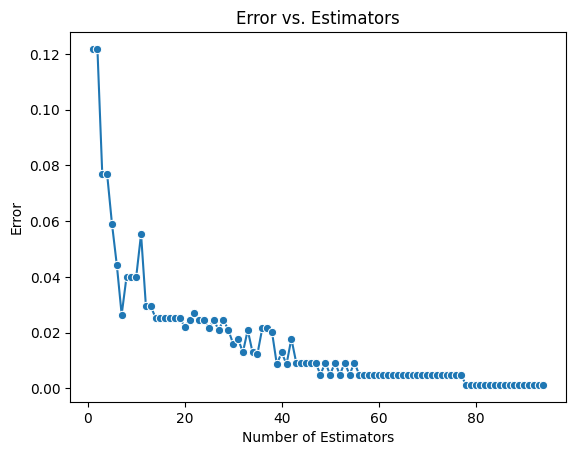

In [ ]:
# Your Code Here

sns.lineplot(x=range(1, len(X.columns)), y=error_list, marker='o', palette = "husl")
plt.title('Error vs. Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Error')
plt.show()


**❓Question**: What's the smallest number of estimators you could pick while ensuring the error is less than .02?

## Model Evaluation

Let's start evaluating our AdaBoost algorithm with 20 estimators.

🤔 Let's think about what metrics would be most important to you if you were about to eat a mushroom based on the results of our AdaBoost algorithm. Would you care more if an edible mushroom was incorrectly labeled poisonous or if a poisonous mushroom was incorrectly labeled edible?


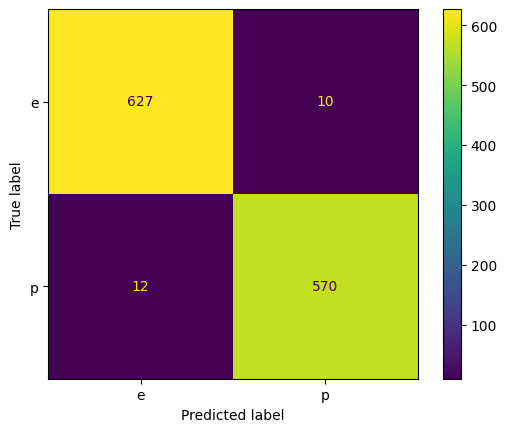

              precision    recall  f1-score   support

           e       0.98      0.98      0.98       637
           p       0.98      0.98      0.98       582

    accuracy                           0.98      1219
   macro avg       0.98      0.98      0.98      1219
weighted avg       0.98      0.98      0.98      1219



In [12]:
model = AdaBoostClassifier(n_estimators=20)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, palette )
plt.show()
print(classification_report(y_test, y_pred))

**❓Question**: What do the confusion matrix and classification report tell us about our AdaBoost model?

✅ **Try it yourself**: Evaluate an AdaBoost model with 40 estimators via a confusion matrix and classification report. How does it compare?

In [ ]:
# Your Code Here

There are pros and cons to each type of ensemble model, and it's important to consider your specific project's needs when weighing your options. For instance, we've discussed how AdaBoost is more prone to overfitting than Random Forests, but the computational cost of Random Forests is much higher.


✅ **Try it yourself**:  Try this problem using a decision tree classifier and a Random Forest instead and compare your results with AdaBoost. Which model type is best suited to this problem?

## Conclusion

💡 **Main idea**: Adaboost is an ensemble method that combines multiple classifiers, called weak learners, in a unique classifier through a weighted linear combination.

### 📑 Sources and Further Reading:

1. [Understanding the AdaBoost Algorithm](https://medium.com/@datasciencewizards/understanding-the-adaboost-algorithm-2e9344d83d9b) | Data Science Wizards
2. [Mushroom Classification Using AdaBoost](https://www.kaggle.com/code/tharunnayak14/mushroom-classification-using-adaboost/notebook) | Tharun Nayak
3. [How to Tell the Difference Between Poisonous and Edible Mushrooms](https://www.wildfooduk.com/articles/how-to-tell-the-difference-between-poisonous-and-edible-mushrooms/) | Eric Biggane
4. [A Visual and Overly Simplified Guide to the AdaBoost Algorithm](https://blog.dailydoseofds.com/p/a-visual-and-overly-simplified-guide-676) | Avi Chawla
5. [Explaining the Success of AdaBoost and Random Forests as
Interpolating Classifiers](https://www.jmlr.org/papers/volume18/15-240/15-240.pdf) | Weiner, Oslan, Bleich

